=== GRAFT SURVIVAL PROBABILITIES ===
  At  1 years: 100.0%
  At  3 years: 97.0%
  At  5 years: 86.7%
  At 10 years: 60.5%


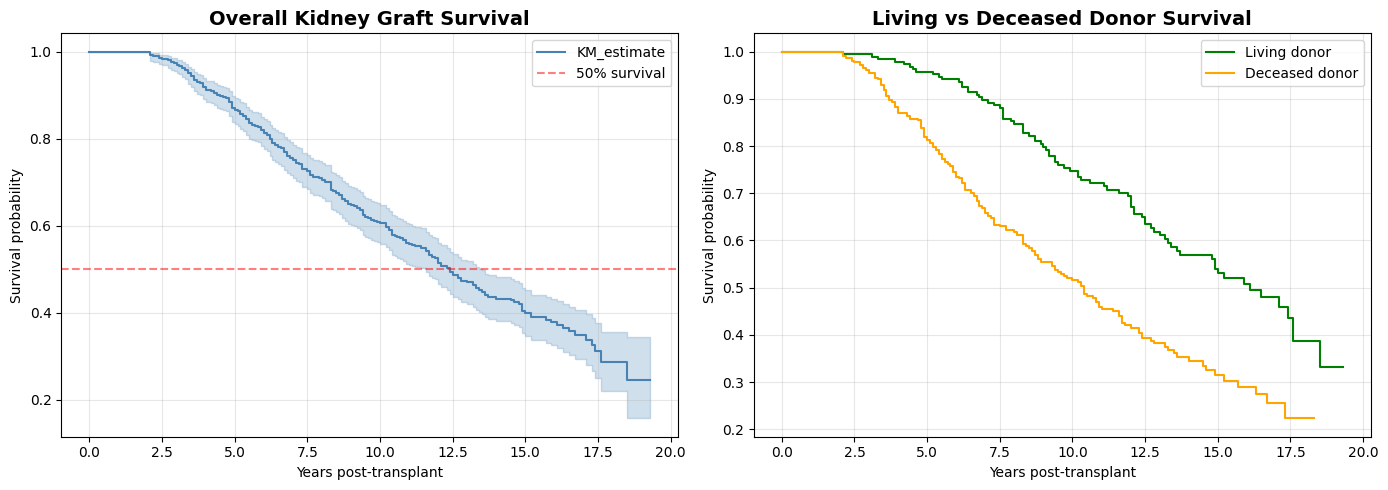


✅ Chart saved to notebooks/survival_curves_day2.png


In [3]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Overall survival curve ─────────────────────
kmf = KaplanMeierFitter()
kmf.fit(df['duration_years'], event_observed=df['graft_failure'])

ax1 = axes[0]
kmf.plot_survival_function(ax=ax1, ci_show=True, color='steelblue')
ax1.set_title('Overall Kidney Graft Survival', fontsize=14, fontweight='bold')
ax1.set_xlabel('Years post-transplant')
ax1.set_ylabel('Survival probability')
ax1.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% survival')
ax1.legend()
ax1.grid(alpha=0.3)

# Print key milestones
print("=== GRAFT SURVIVAL PROBABILITIES ===")
for yr in [1, 3, 5, 10]:
    prob = kmf.survival_function_at_times(yr).values[0]
    print(f"  At {yr:2d} years: {prob*100:.1f}%")

# ── Plot 2: Living vs Deceased donor ───────────────────
ax2 = axes[1]
for val, label, color in [(1, 'Living donor', 'green'), (0, 'Deceased donor', 'orange')]:
    mask = df['living_donor'] == val
    kmf2 = KaplanMeierFitter()
    kmf2.fit(df[mask]['duration_years'], event_observed=df[mask]['graft_failure'], label=label)
    kmf2.plot_survival_function(ax=ax2, ci_show=False, color=color)

ax2.set_title('Living vs Deceased Donor Survival', fontsize=14, fontweight='bold')
ax2.set_xlabel('Years post-transplant')
ax2.set_ylabel('Survival probability')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/survival_curves_day2.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved to notebooks/survival_curves_day2.png")